In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/chamathkumarathunge/personality-dataset/personality_dataset.csv


In [2]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("/kaggle/input/datasets/chamathkumarathunge/personality-dataset/personality_dataset.csv")

df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [4]:
print("Shape:", df.shape)

df.info()

Shape: (2900, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   object 
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   object 
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [5]:
df.isnull().sum()

Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

In [6]:
df.describe(include='object')

,Stage_fear,Drained_after_socializing,Personality
count,2827,2848,2900
unique,2,2,2
top,No,No,Extrovert
freq,1417,1441,1491


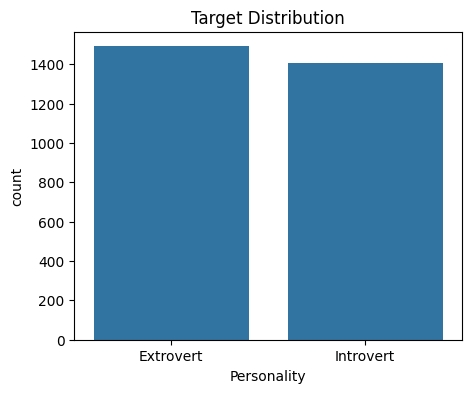

In [7]:
plt.figure(figsize=(5,4))

sns.countplot(data=df,x="Personality")

plt.title("Target Distribution")
plt.show()

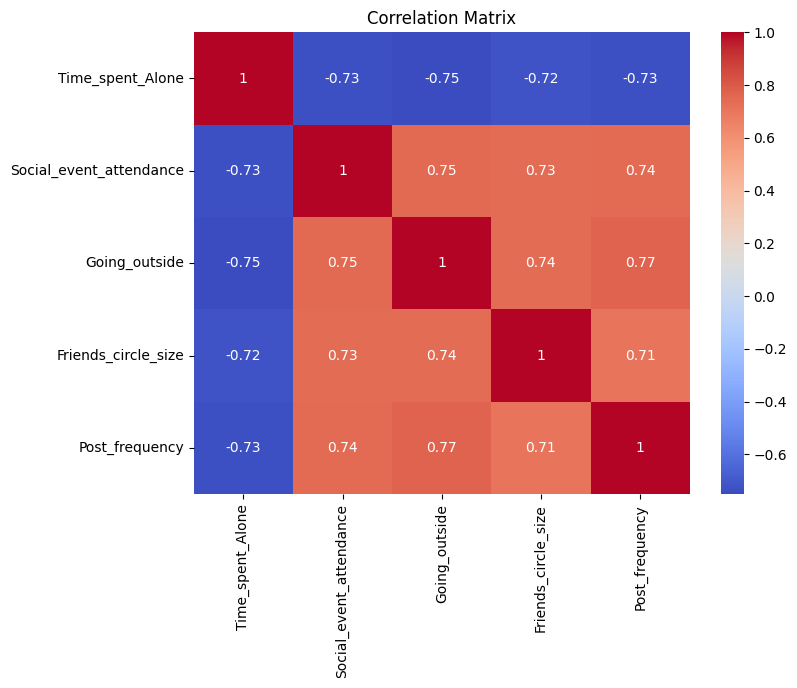

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

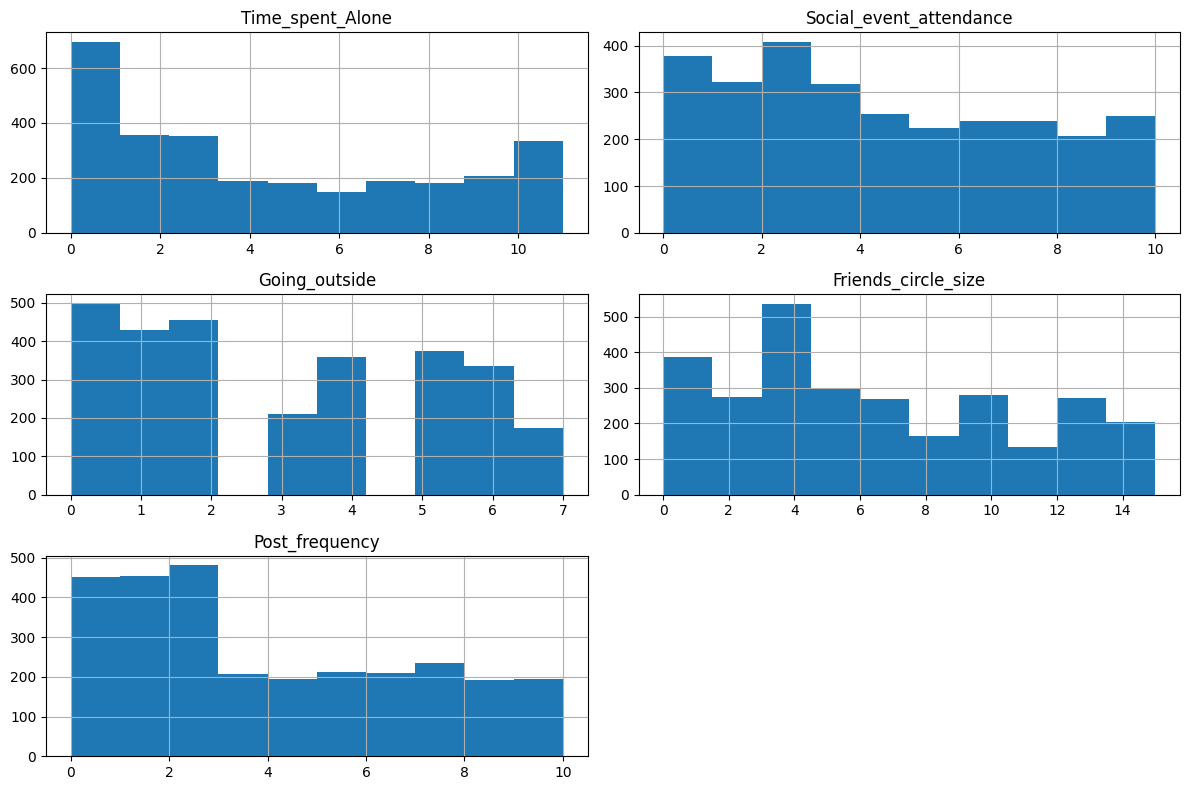

In [9]:
df.hist(figsize=(12,8))

plt.tight_layout()
plt.show()

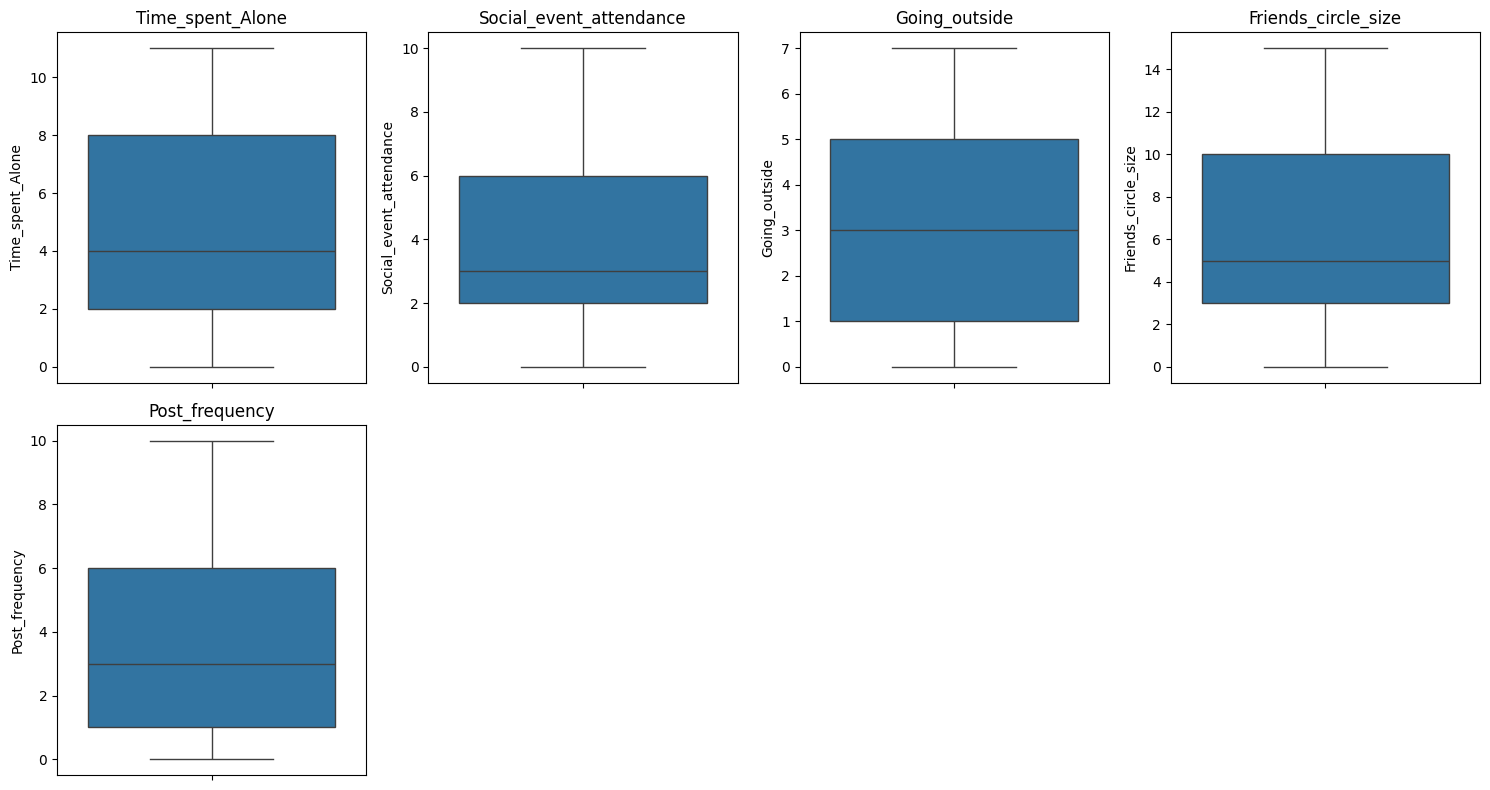

In [10]:
numeric_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,8))

for i,col in enumerate(numeric_columns):

    plt.subplot(2,4,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

In [11]:
num_cols = df.select_dtypes(include=np.number).columns

num_imputer = SimpleImputer(strategy="median")

df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_cols = df.select_dtypes(include="object").columns

cat_imputer = SimpleImputer(strategy="most_frequent")

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [12]:
encoders = {}

for col in df.select_dtypes(include="object").columns:

    encoder = LabelEncoder()

    df[col] = encoder.fit_transform(df[col])

    encoders[col] = encoder

df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,0,4.0,6.0,0,13.0,5.0,0
1,9.0,1,0.0,0.0,1,0.0,3.0,1
2,9.0,1,1.0,2.0,1,5.0,2.0,1
3,0.0,0,6.0,7.0,0,14.0,8.0,0
4,3.0,0,9.0,4.0,0,8.0,5.0,0


In [13]:
X = df.drop("Personality",axis=1)

y = df["Personality"]

In [14]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(2320, 7)
(580, 7)


In [15]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB


models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "Extra Trees": ExtraTreesClassifier(random_state=42),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(),

    "Naive Bayes": GaussianNB()

}

In [16]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

results = []

trained_models = {}

for name,model in models.items():

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test,pred)

    results.append([name,acc])

    trained_models[name] = model

    print("="*60)

    print(name)

    print("Accuracy:",round(acc,4))

    print(classification_report(y_test,pred))

Logistic Regression
Accuracy: 0.9172
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       298
           1       0.90      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580

Decision Tree
Accuracy: 0.8569
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       298
           1       0.84      0.87      0.86       282

    accuracy                           0.86       580
   macro avg       0.86      0.86      0.86       580
weighted avg       0.86      0.86      0.86       580

Random Forest
Accuracy: 0.9017
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       298
           1       0.89      0.90      0.90       282

    accuracy                           0.90       580
   macro avg       0.90      

In [17]:
results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
0,Logistic Regression,0.917241
3,Gradient Boosting,0.917241
6,SVM,0.917241
7,Naive Bayes,0.917241
5,KNN,0.912069
2,Random Forest,0.901724
4,Extra Trees,0.896552
1,Decision Tree,0.856897


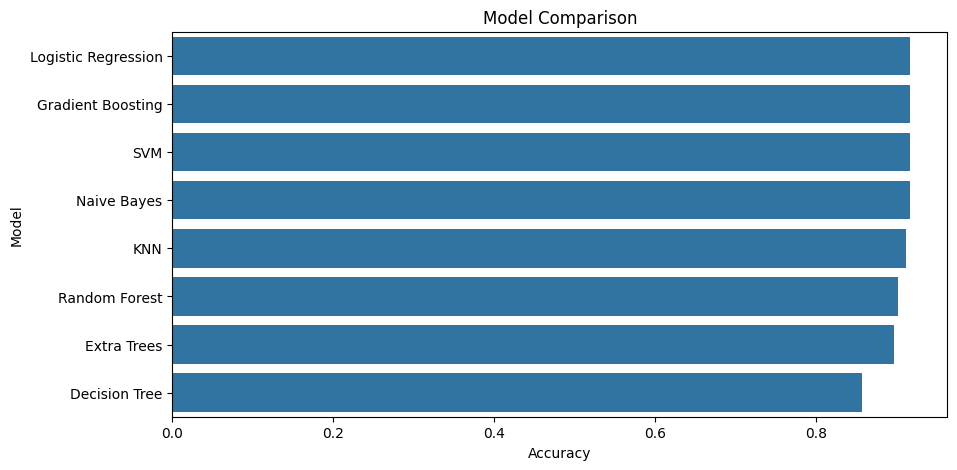

In [18]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title("Model Comparison")

plt.show()

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=['accuracy', 'precision', 'recall', 'f1']
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy": scores['test_accuracy'].mean(),
        "CV Precision": scores['test_precision'].mean(),
        "CV Recall": scores['test_recall'].mean(),
        "CV F1 Score": scores['test_f1'].mean()
    })

In [20]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="CV Accuracy",
    ascending=False
)

cv_results_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1 Score
6,SVM,0.934483,0.923239,0.943936,0.933367
3,Gradient Boosting,0.934138,0.922618,0.943936,0.933046
7,Naive Bayes,0.934138,0.923184,0.943227,0.932986
5,KNN,0.927586,0.914646,0.938972,0.926503
0,Logistic Regression,0.924483,0.921650,0.923364,0.922412
2,Random Forest,0.919310,0.916229,0.918384,0.917003
4,Extra Trees,0.914138,0.917082,0.905608,0.911044
1,Decision Tree,0.876552,0.876297,0.868703,0.872346


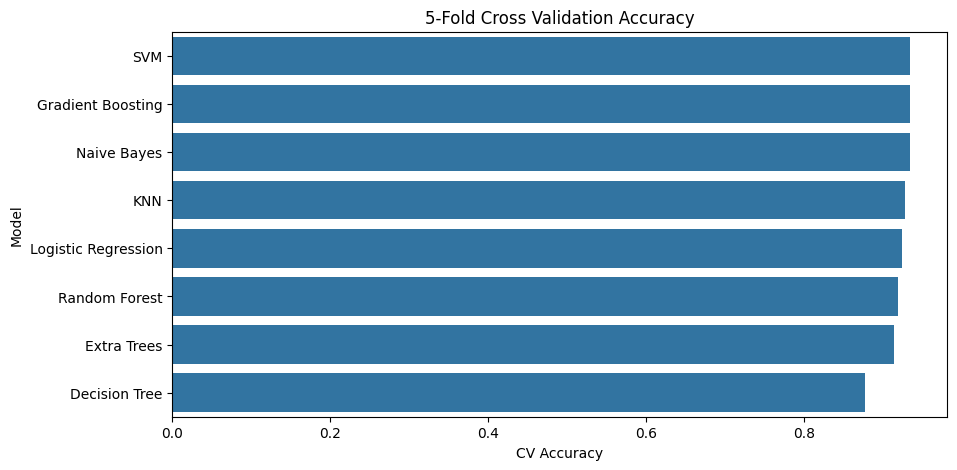

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=cv_results_df,
    x="CV Accuracy",
    y="Model"
)

plt.title("5-Fold Cross Validation Accuracy")

plt.show()

In [22]:
cv_results_df = cv_results_df.round(4)

cv_results_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1 Score
6,SVM,0.9345,0.9232,0.9439,0.9334
3,Gradient Boosting,0.9341,0.9226,0.9439,0.9330
7,Naive Bayes,0.9341,0.9232,0.9432,0.9330
5,KNN,0.9276,0.9146,0.9390,0.9265
0,Logistic Regression,0.9245,0.9217,0.9234,0.9224
2,Random Forest,0.9193,0.9162,0.9184,0.9170
4,Extra Trees,0.9141,0.9171,0.9056,0.9110
1,Decision Tree,0.8766,0.8763,0.8687,0.8723


In [23]:
cv_results_df["Overall Score"] = (
    cv_results_df["CV Accuracy"] +
    cv_results_df["CV Precision"] +
    cv_results_df["CV Recall"] +
    cv_results_df["CV F1 Score"]
) / 4

cv_results_df = cv_results_df.sort_values(
    by="Overall Score",
    ascending=False
)

cv_results_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1 Score,Overall Score
6,SVM,0.9345,0.9232,0.9439,0.9334,0.933750
3,Gradient Boosting,0.9341,0.9226,0.9439,0.9330,0.933400
7,Naive Bayes,0.9341,0.9232,0.9432,0.9330,0.933375
5,KNN,0.9276,0.9146,0.9390,0.9265,0.926925
0,Logistic Regression,0.9245,0.9217,0.9234,0.9224,0.923000
2,Random Forest,0.9193,0.9162,0.9184,0.9170,0.917725
4,Extra Trees,0.9141,0.9171,0.9056,0.9110,0.911950
1,Decision Tree,0.8766,0.8763,0.8687,0.8723,0.873475


In [24]:
best_model_name = cv_results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: SVM


In [25]:
best_model = models[best_model_name]

best_model.fit(X_train, y_train)

SVC()

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

pred = best_model.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, pred),4))
print("Precision:", round(precision_score(y_test, pred),4))
print("Recall   :", round(recall_score(y_test, pred),4))
print("F1 Score :", round(f1_score(y_test, pred),4))

print("\nClassification Report\n")
print(classification_report(y_test, pred))

Accuracy : 0.9172
Precision: 0.8953
Recall   : 0.9397
F1 Score : 0.917

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.90      0.92       298
           1       0.90      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



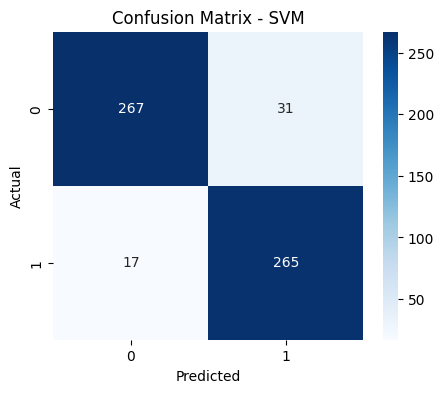

In [27]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")

plt.show()

In [28]:
import joblib

joblib.dump(best_model, "personality_model.pkl")

print("Best model saved successfully.")

joblib.dump(encoders, "label_encoders.pkl")

print("Encoders saved successfully.")

Best model saved successfully.
Encoders saved successfully.
